In [2]:
%load_ext autoreload 
%autoreload 2
import xarray as xr
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from scipy.stats import binned_statistic
from src.loading import (
    load_gpm_feature_stats,
    load_imerg_feature_stats,
    load_dyamond_feature_stats,
    load_archived_dyamond_feature_stats,
     load_pickled_archived_features
)
from src.plotting import (
    array_midpoints,
    discrete_cmap,
    plot_mean_stat,
    gpm_area_factor,
    gpm_area_factor_accurate,
)

Compare GPM to IMERG and DYAMOND at 30 min accumulations

Text(0.5, 1.0, '0p1 deg, Edge Frac Max 0.50')

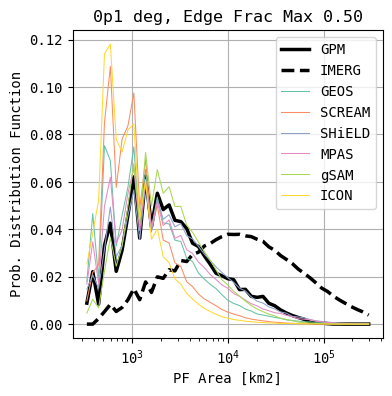

In [3]:
# Load features
edge_frac_max = 0.5
maxpr_min = 10
feature_stats_dict = {
    'GPM': load_gpm_feature_stats(threshold=1.0, res="0p1", edge_frac_max=edge_frac_max),
    'IMERG': load_imerg_feature_stats(threshold=1, edge_frac_max=edge_frac_max, maxpr_min=maxpr_min),
    'GEOS': load_dyamond_feature_stats('GEOS-3km', edge_frac_max=edge_frac_max, maxpr_min=maxpr_min),
    'SCREAM': load_dyamond_feature_stats('SCREAM-3km', edge_frac_max=edge_frac_max, maxpr_min=maxpr_min),
    'SHiELD': load_dyamond_feature_stats('SHiELD-3km', edge_frac_max=edge_frac_max, maxpr_min=maxpr_min),
    'MPAS': load_dyamond_feature_stats('MPAS-3km', edge_frac_max=edge_frac_max, maxpr_min=maxpr_min),
    'gSAM': load_dyamond_feature_stats('gSAM-4km', edge_frac_max=edge_frac_max, maxpr_min=maxpr_min),
    'ICON': load_dyamond_feature_stats('ICON-SAP-5km', edge_frac_max=edge_frac_max, maxpr_min=maxpr_min),
}

fig, ax = plt.subplots(figsize=(4,4))

# Plot PDF
for source, df in feature_stats_dict.items():
    bins = np.logspace(2.5, 5.5, 50)
    counts = binned_statistic(
        df['area_km2'],
        None,
        'count', 
        bins=bins
    ).statistic
    pdf = counts / counts.sum()
    if source == 'GPM':
        color='black'
        lw = 2.5
        linestyle='solid'
    elif source == "IMERG":
        color='black'
        lw = 2.5
        linestyle='dashed'
    else:
        color=None
        lw = 0.75
        linestyle='solid'

    ax.plot(
        array_midpoints(bins),
        pdf,
        label=source,
        color=color,
        lw=lw,
        linestyle=linestyle
    )

ax.set_xscale('log')
ax.legend()
ax.grid()
ax.set_xlabel('PF Area [km2]')
ax.set_ylabel('Prob. Distribution Function')
ax.set_title(f'0p1 deg, Edge Frac Max {edge_frac_max:.2f}')

Looking at 0p05 features

Text(0.5, 1.0, '0p05 deg, Swath Edge Pixels Max 0.00')

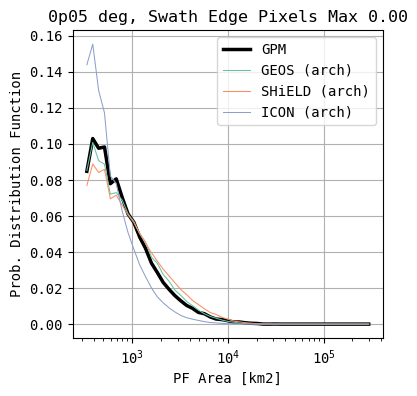

In [4]:
swath_edge_px_max = 0
_MAXPR_MIN = 10
feature_stats_dict = {
    'GPM': load_gpm_feature_stats(threshold=1.0, res="0p05", edge_frac_max=0),
    'GEOS (arch)': load_archived_dyamond_feature_stats('GEOS-3km', res="0p05", swath_edge_px_max=swath_edge_px_max, maxpr_min=_MAXPR_MIN),
    'SHiELD (arch)': load_archived_dyamond_feature_stats('SHiELD-3km', res="0p05", swath_edge_px_max=swath_edge_px_max, maxpr_min=_MAXPR_MIN),
    'ICON (arch)': load_archived_dyamond_feature_stats('ICON-SAP-5km', res="0p05", swath_edge_px_max=swath_edge_px_max, maxpr_min=_MAXPR_MIN),
}

fig, ax = plt.subplots(figsize=(4,4))

# Plot PDF
for source, df in feature_stats_dict.items():
    bins = np.logspace(2.5, 5.5, 50)
    counts = binned_statistic(
        df['area_km2'],
        None,
        'count', 
        bins=bins
    ).statistic
    pdf = counts / counts.sum()
    if source == 'GPM':
        color='black'
        lw = 2.5
        linestyle='solid'
    else:
        color=None
        lw = 0.75
        linestyle='solid'

    ax.plot(
        array_midpoints(bins),
        pdf,
        label=source,
        color=color,
        lw=lw,
        linestyle=linestyle
    )

ax.set_xscale('log')
ax.legend()
ax.grid()
ax.set_xlabel('PF Area [km2]')
ax.set_ylabel('Prob. Distribution Function')
ax.set_title(f'0p05 deg, Swath Edge Pixels Max {swath_edge_px_max:.2f}')

Text(0.5, 1.0, '0p05 deg, Swath Edge Pixels Max 0.00')

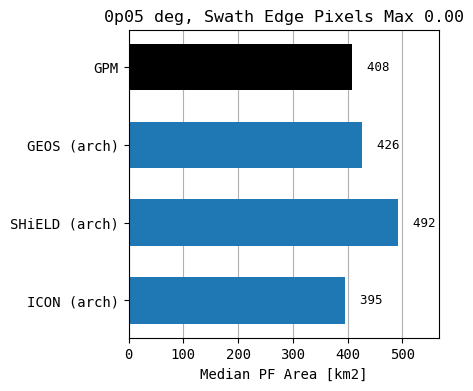

In [5]:
# Median PF size for the 0p05 sources loaded above
medians = {source: df['area_km2'].median() for source, df in feature_stats_dict.items()}

fig, ax = plt.subplots(figsize=(4,4))

sources = list(medians)
ypos = np.arange(len(sources))[::-1]
colors_ = ['black' if s == 'GPM' else 'tab:blue' for s in sources]
ax.barh(ypos, list(medians.values()), color=colors_, height=0.6)

for y, source in zip(ypos, sources):
    ax.text(medians[source], y, f'  {medians[source]:.0f}', va='center', fontsize=9)

ax.set_xlim(0, max(medians.values()) * 1.15)
ax.set_yticks(ypos)
ax.set_yticklabels(sources)
ax.set_xlabel('Median PF Area [km2]')
ax.grid(axis='x')
ax.set_axisbelow(True)
ax.set_title(f'0p05 deg, Swath Edge Pixels Max {swath_edge_px_max:.2f}')

Looking at archived, pickled data

125
125
125
125
125


Text(0.5, 1.0, 'Archived pickled features, no cuts')

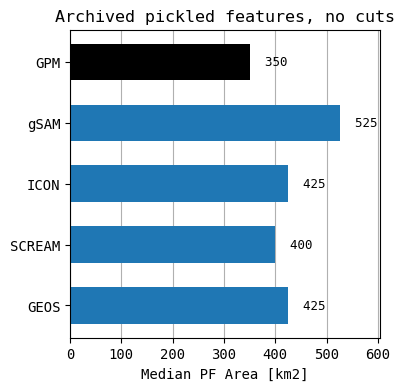

In [6]:
old_features = load_pickled_archived_features()

# These files have no area_km2, so approximate it from the pixel count at 5 km spacing
old_medians = {}
for source, df in old_features.items():
    area = df['number_pixels']*25
    old_medians[source] = area.median()
    print(area.min())

fig, ax = plt.subplots(figsize=(4,4))

sources = list(old_medians)
ypos = np.arange(len(sources))[::-1]
colors_ = ['black' if s == 'GPM' else 'tab:blue' for s in sources]
ax.barh(ypos, list(old_medians.values()), color=colors_, height=0.6)

for y, source in zip(ypos, sources):
    ax.text(old_medians[source], y, f'  {old_medians[source]:.0f}', va='center', fontsize=9)

ax.set_xlim(0, max(old_medians.values()) * 1.15)
ax.set_yticks(ypos)
ax.set_yticklabels(sources)
ax.set_xlabel('Median PF Area [km2]')
ax.grid(axis='x')
ax.set_axisbelow(True)
ax.set_title('Archived pickled features, no cuts')

In [7]:
df

source_file,time,feature_id,is_complete,mean_latitude,mean_longitude,max_longitude,min_longitude,max_latitude,min_latitude,centroid_y_index,centroid_x_index,number_pixels,number_10mmhr_pixels,largest_10mmhr_cluster,largest_10mmhr_cluster_max_precip,number_10mmhr_clusters,total_precip,max_precip,min_precip,mean_precip,swath_idx,model,var
str,i64,i64,bool,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,f64,i64,f64,f64,f64,f64,i64,str,str
"""/home/b/b382284/scratch/remapp…",1580515200000000000,59,true,-10.319444,2.308333,2.375,2.225,-10.275,-10.375,193.111111,45.666667,9,2,2,17.925673,1,52.206341,17.925673,1.061552,5.800704,0,"""GEOS-3km""","""pr"""
"""/home/b/b382284/scratch/remapp…",1580515200000000000,60,true,-9.692647,3.375,3.525,3.225,-9.625,-9.775,205.647059,67.0,17,2,2,12.781194,1,64.411537,12.781194,1.18437,3.788914,0,"""GEOS-3km""","""pr"""
"""/home/b/b382284/scratch/remapp…",1580515200000000000,61,true,-9.261667,0.961667,1.175,0.775,-9.025,-9.425,214.266667,18.733333,30,4,4,19.629311,1,133.004501,19.629311,1.002579,4.433484,0,"""GEOS-3km""","""pr"""
"""/home/b/b382284/scratch/remapp…",1580515200000000000,65,true,-3.672674,6.761047,6.975,6.525,-3.375,-3.925,326.046512,134.72093,43,16,9,103.395676,3,593.571533,103.395676,1.109874,13.803989,0,"""GEOS-3km""","""pr"""
"""/home/b/b382284/scratch/remapp…",1580515200000000000,69,true,-3.55,7.538636,7.675,7.425,-3.475,-3.625,328.5,150.272727,22,9,9,40.488762,1,230.787811,40.488762,1.232152,10.490355,0,"""GEOS-3km""","""pr"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""/home/b/b382284/scratch/remapp…",1583010000000000000,116,true,1.3625,18.902083,19.075,18.675,1.425,1.275,426.75,377.541667,24,9,9,45.57658,1,242.499939,45.57658,1.047609,10.104164,148,"""GEOS-3km""","""pr"""
"""/home/b/b382284/scratch/remapp…",1583010000000000000,123,true,1.983333,19.116667,19.175,19.075,2.025,1.925,439.166667,381.833333,6,2,2,23.644011,1,54.62257,23.644011,1.202026,9.103762,148,"""GEOS-3km""","""pr"""
"""/home/b/b382284/scratch/remapp…",1583010000000000000,125,true,2.5775,19.0325,19.175,18.875,2.625,2.525,451.05,380.15,20,9,9,36.514183,1,214.134369,36.514183,1.392426,10.706718,148,"""GEOS-3km""","""pr"""


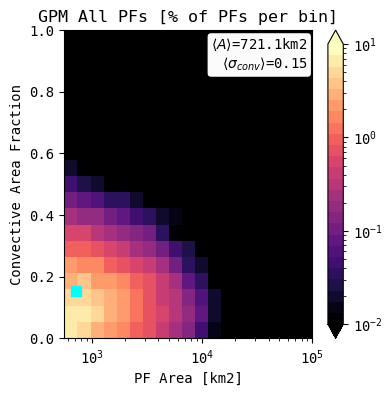

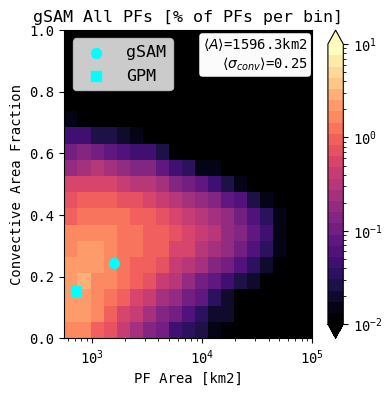

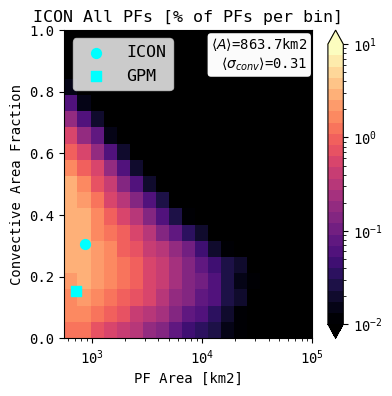

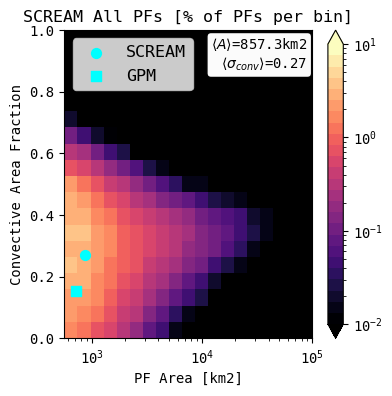

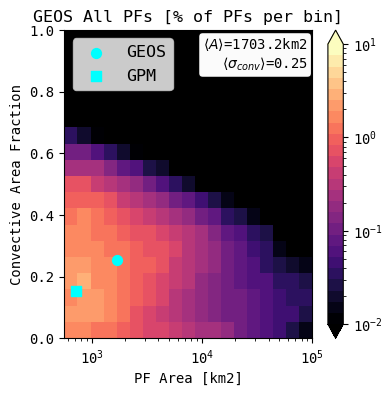

In [8]:
# Joint PDF of PF area and convective area fraction, one figure per source
x_bins = np.logspace(2.75, 5, 20)
y_bins = np.linspace(0, 1, 20)
cmap = discrete_cmap('magma', 25)
cmap.set_under('black')
cmap.set_bad('black')
norm = colors.LogNorm(vmin=1e-2, vmax=1e1)

mean_color = 'cyan'
obs_marker = 's'
model_marker = 'o'

gpm_x = old_features['GPM']['number_pixels'] * gpm_area_factor()
gpm_y = old_features['GPM']['number_10mmhr_pixels'] / old_features['GPM']['number_pixels']

for source, df in old_features.items():
    x_all = df['number_pixels'] * gpm_area_factor()
    y_all = df['number_10mmhr_pixels'] / df['number_pixels']

    fig, ax, data = plot_mean_stat(
        x_data=x_all,
        y_data=y_all,
        x_bins=x_bins,
        y_bins=y_bins,
        data_to_bin=None,
        statistic='count',
        density=True,
        cmap=cmap,
        norm=norm,
        return_data=True,
        figsize=(4,4),
    )

    # Mean of this source, plus GPM as a reference point for the models
    x_mean, y_mean = np.nanmean(x_all), np.nanmean(y_all)
    marker = obs_marker if source == 'GPM' else model_marker
    ax.scatter(x_mean, y_mean, color=mean_color, marker=marker, s=50, label=source)
    if source != 'GPM':
        ax.scatter(np.nanmean(gpm_x), np.nanmean(gpm_y), color=mean_color, marker=obs_marker, s=50, label='GPM')
        ax.legend(loc='upper left', fontsize=12)

    text = fr"$\langle A\rangle$={x_mean:.1f}km2" + "\n" + rf"$\langle\sigma_{{conv}}\rangle$={y_mean:.2f}"
    ax.text(
        0.98, 0.98, text,
        transform=ax.transAxes,
        ha='right',
        va='top',
        fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.99, edgecolor='black'),
    )

    ax.set_xscale('log')
    ax.set_xlabel('PF Area [km2]')
    ax.set_ylabel('Convective Area Fraction')
    ax.set_title(f'{source} All PFs [% of PFs per bin]')

Text(0.5, 1.0, 'Archived pickled features, no cuts')

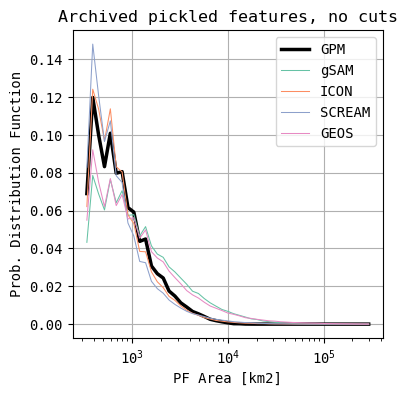

In [9]:
# PDF of feature size for each archived source
fig, ax = plt.subplots(figsize=(4,4))

for source, df in old_features.items():
    area = df['number_pixels'] * gpm_area_factor()
    bins = np.logspace(2.5, 5.5, 50)
    counts = binned_statistic(
        area,
        None,
        'count', 
        bins=bins
    ).statistic
    pdf = counts / counts.sum()
    if source == 'GPM':
        color='black'
        lw = 2.5
    else:
        color=None
        lw = 0.75

    ax.plot(
        array_midpoints(bins),
        pdf,
        label=source,
        color=color,
        lw=lw
    )

ax.set_xscale('log')
ax.legend()
ax.grid()
ax.set_xlabel('PF Area [km2]')
ax.set_ylabel('Prob. Distribution Function')
ax.set_title('Archived pickled features, no cuts')

Text(0.5, 1.0, 'New features, 0p1 deg, Edge Frac Max 0.50')

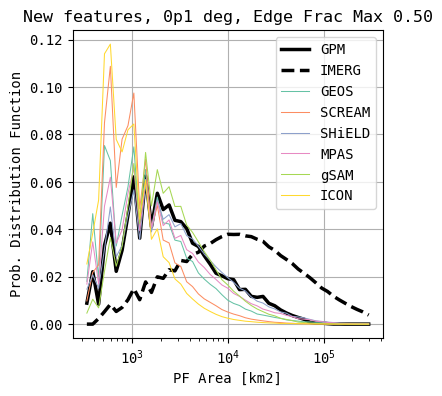

In [10]:
# Same PDF for the new 0p1 deg data, for comparison with the archived features above
new_features = {
    'GPM': load_gpm_feature_stats(threshold=1.0, res="0p1", edge_frac_max=edge_frac_max),
    'IMERG': load_imerg_feature_stats(threshold=1, edge_frac_max=edge_frac_max, maxpr_min=maxpr_min),
    'GEOS': load_dyamond_feature_stats('GEOS-3km', edge_frac_max=edge_frac_max, maxpr_min=maxpr_min),
    'SCREAM': load_dyamond_feature_stats('SCREAM-3km', edge_frac_max=edge_frac_max, maxpr_min=maxpr_min),
    'SHiELD': load_dyamond_feature_stats('SHiELD-3km', edge_frac_max=edge_frac_max, maxpr_min=maxpr_min),
    'MPAS': load_dyamond_feature_stats('MPAS-3km', edge_frac_max=edge_frac_max, maxpr_min=maxpr_min),
    'gSAM': load_dyamond_feature_stats('gSAM-4km', edge_frac_max=edge_frac_max, maxpr_min=maxpr_min),
    'ICON': load_dyamond_feature_stats('ICON-SAP-5km', edge_frac_max=edge_frac_max, maxpr_min=maxpr_min),
}

fig, ax = plt.subplots(figsize=(4,4))

for source, df in new_features.items():
    bins = np.logspace(2.5, 5.5, 50)
    counts = binned_statistic(
        df['area_km2'],
        None,
        'count', 
        bins=bins
    ).statistic
    pdf = counts / counts.sum()
    if source == 'GPM':
        color='black'
        lw = 2.5
        linestyle='solid'
    elif source == 'IMERG':
        color='black'
        lw = 2.5
        linestyle='dashed'
    else:
        color=None
        lw = 0.75
        linestyle='solid'

    ax.plot(
        array_midpoints(bins),
        pdf,
        label=source,
        color=color,
        lw=lw,
        linestyle=linestyle
    )

ax.set_xscale('log')
ax.legend()
ax.grid()
ax.set_xlabel('PF Area [km2]')
ax.set_ylabel('Prob. Distribution Function')
ax.set_title(f'New features, 0p1 deg, Edge Frac Max {edge_frac_max:.2f}')

Claude, write below here

**Question:** does the answer to "do the GSRMs over- or underestimate feature size relative to observations" depend on whether the per-pixel area carries the latitude correction?

In [11]:
# Feature area under two conventions, for both datasets.
#   uncorrected: every pixel is the equatorial square, R^2 * dres^2 (what gpm_area_factor does)
#   corrected:   the exact spherical cell area at the feature latitude
# The new pipeline's area_km2 is already latitude aware, so it is the corrected version
# there and size_px * (equatorial area) is the uncorrected one. The archived pickles only
# store number_pixels, so both conventions are built from it.
areas = {
    'archived 0p05': {
        source: {
            'uncorrected': df['number_pixels'] * gpm_area_factor_accurate(0.0, res=0.05),
            'corrected': df['number_pixels'] * gpm_area_factor_accurate(df['mean_latitude'], res=0.05),
            'abs_lat': df['mean_latitude'].abs(),
        }
        for source, df in old_features.items()
    },
    'new 0p1': {
        source: {
            'uncorrected': df['size_px'] * gpm_area_factor_accurate(0.0, res=0.1),
            'corrected': df['area_km2'],
            'abs_lat': df['centroid_lat'].abs(),
        }
        for source, df in new_features.items()
    },
}

for dataset, sources in areas.items():
    print(f'\n{dataset}')
    print(f'{"source":8s} {"med unc":>9s} {"med corr":>9s} {"mean unc":>9s} {"mean corr":>9s} {"<|lat|>":>8s}')
    for source, a in sources.items():
        print(f'{source:8s} {a["uncorrected"].median():9.0f} {a["corrected"].median():9.0f} '
              f'{a["uncorrected"].mean():9.0f} {a["corrected"].mean():9.0f} {a["abs_lat"].mean():8.1f}')


archived 0p05
source     med unc  med corr  mean unc mean corr  <|lat|>
GPM            433       429       721       710      8.4
gSAM           649       648      1596      1574      8.5
ICON           525       522       864       851      8.4
SCREAM         495       485       857       844      8.3
GEOS           525       524      1703      1678      8.3

new 0p1
source     med unc  med corr  mean unc mean corr  <|lat|>
GPM           2102      2027      5017      4940      8.0
IMERG        12488     12277     35530     35102      7.7
GEOS          1236      1234      3425      3381      7.7
SCREAM         989       987      1914      1888      7.9
SHiELD        2102      2058      5464      5386      8.6
MPAS          1484      1484      4618      4543      8.9
gSAM          2102      2058      3988      3938      7.9
ICON           866       837      1465      1438      9.3


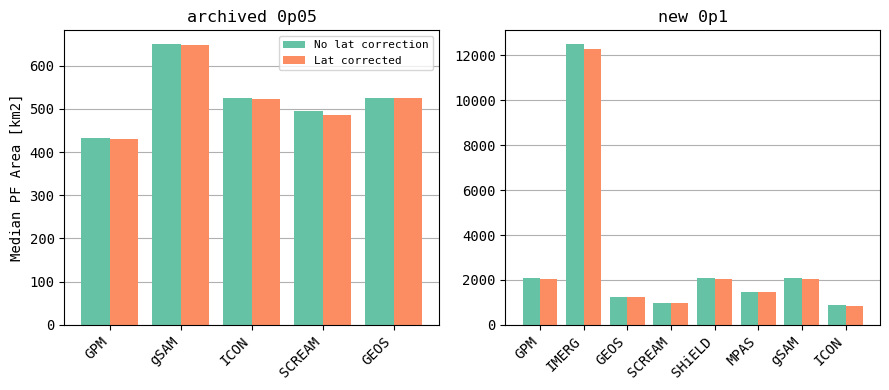

In [12]:
# Median feature size under both conventions
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

for ax, (dataset, sources) in zip(axes, areas.items()):
    names = list(sources)
    x = np.arange(len(names))
    w = 0.4
    ax.bar(x - w/2, [sources[s]['uncorrected'].median() for s in names], w, label='No lat correction')
    ax.bar(x + w/2, [sources[s]['corrected'].median() for s in names], w, label='Lat corrected')
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=45, ha='right')
    ax.set_title(dataset)
    ax.grid(axis='y')
    ax.set_axisbelow(True)

axes[0].set_ylabel('Median PF Area [km2]')
axes[0].legend(fontsize=8)
fig.tight_layout()

archived 0p05  median gSAM     1.500 ->  1.510
archived 0p05  median ICON     1.214 ->  1.215
archived 0p05  median SCREAM   1.143 ->  1.130
archived 0p05  median GEOS     1.214 ->  1.221
archived 0p05  mean   gSAM     2.214 ->  2.216
archived 0p05  mean   ICON     1.198 ->  1.197
archived 0p05  mean   SCREAM   1.189 ->  1.189
archived 0p05  mean   GEOS     2.362 ->  2.362
new 0p1        median IMERG    5.941 ->  6.056
new 0p1        median GEOS     0.588 ->  0.609
new 0p1        median SCREAM   0.471 ->  0.487
new 0p1        median SHiELD   1.000 ->  1.015
new 0p1        median MPAS     0.706 ->  0.732
new 0p1        median gSAM     1.000 ->  1.015
new 0p1        median ICON     0.412 ->  0.413
new 0p1        mean   IMERG    7.082 ->  7.106
new 0p1        mean   GEOS     0.683 ->  0.685
new 0p1        mean   SCREAM   0.382 ->  0.382
new 0p1        mean   SHiELD   1.089 ->  1.090
new 0p1        mean   MPAS     0.921 ->  0.920
new 0p1        mean   gSAM     0.795 ->  0.797
new 0p1      

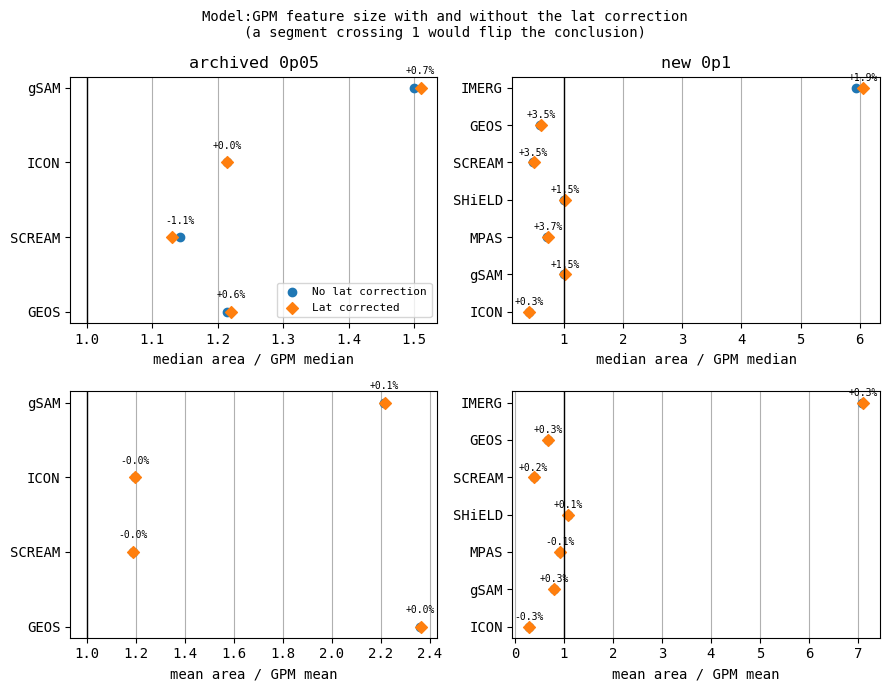

In [13]:
# The answer: size relative to GPM under both conventions. The sign of the bias is set by
# which side of 1 a source sits on, so the conclusion only changes if a segment crosses 1.
def plot_ratio_shift(sources, ref='GPM', stat='median', ax=None, title=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(4.5, 4))
    others = [s for s in sources if s != ref]
    y = np.arange(len(others))[::-1]
    ref_unc = getattr(sources[ref]['uncorrected'], stat)()
    ref_cor = getattr(sources[ref]['corrected'], stat)()
    r_unc = np.array([getattr(sources[s]['uncorrected'], stat)() / ref_unc for s in others])
    r_cor = np.array([getattr(sources[s]['corrected'], stat)() / ref_cor for s in others])

    flips = (r_unc - 1) * (r_cor - 1) < 0
    for yi, ru, rc, fl in zip(y, r_unc, r_cor, flips):
        ax.plot([ru, rc], [yi, yi], color='red' if fl else 'gray', lw=2, zorder=1)
        ax.text(max(ru, rc), yi + 0.18, f'{100*(rc/ru-1):+.1f}%', fontsize=7, ha='center')
    ax.scatter(r_unc, y, marker='o', color='tab:blue', zorder=2, label='No lat correction')
    ax.scatter(r_cor, y, marker='D', color='tab:orange', zorder=2, label='Lat corrected')
    ax.axvline(1, color='black', lw=1)
    ax.set_yticks(y)
    ax.set_yticklabels(others)
    ax.set_xlabel(f'{stat} area / {ref} {stat}')
    ax.grid(axis='x')
    ax.set_axisbelow(True)
    if title:
        ax.set_title(title)
    return ax, dict(zip(others, zip(r_unc, r_cor, flips)))


fig, axes = plt.subplots(2, 2, figsize=(9, 7))
shifts = {}
for col, (dataset, sources) in enumerate(areas.items()):
    for row, stat in enumerate(['median', 'mean']):
        _, shifts[(dataset, stat)] = plot_ratio_shift(
            sources, stat=stat, ax=axes[row, col], title=dataset if row == 0 else None
        )
axes[0, 0].legend(fontsize=8, loc='lower right')
fig.suptitle('Model:GPM feature size with and without the lat correction\n'
             '(a segment crossing 1 would flip the conclusion)', fontsize=10)
fig.tight_layout()

for (dataset, stat), d in shifts.items():
    for source, (ru, rc, fl) in d.items():
        print(f'{dataset:14s} {stat:6s} {source:7s} {ru:6.3f} -> {rc:6.3f}' + ('  <-- FLIPS' if fl else ''))

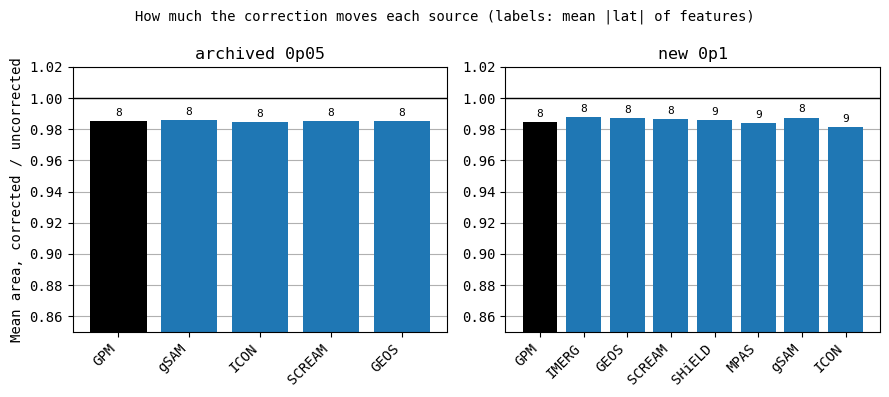

In [14]:
# Why the two datasets behave differently: the correction only moves a model:GPM ratio if
# the two sit at different latitudes. Bars are the mean shrinkage, labels the mean |lat|.
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

for ax, (dataset, sources) in zip(axes, areas.items()):
    names = list(sources)
    factors = [sources[s]['corrected'].mean() / sources[s]['uncorrected'].mean() for s in names]
    lats = [sources[s]['abs_lat'].mean() for s in names]
    x = np.arange(len(names))
    ax.bar(x, factors, color=['black' if s == 'GPM' else 'tab:blue' for s in names])
    for xi, f, la in zip(x, factors, lats):
        ax.text(xi, f + 0.002, f'{la:.0f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=45, ha='right')
    ax.set_ylim(0.85, 1.02)
    ax.axhline(1, color='black', lw=1)
    ax.set_title(dataset)
    ax.grid(axis='y')
    ax.set_axisbelow(True)

axes[0].set_ylabel('Mean area, corrected / uncorrected')
fig.suptitle('How much the correction moves each source (labels: mean |lat| of features)', fontsize=10)
fig.tight_layout()

GPM features inside |lat| <= 20: 100.0%
matched median IMERG    5.941 ->  6.056
matched median GEOS     0.588 ->  0.609
matched median SCREAM   0.471 ->  0.487
matched median SHiELD   1.000 ->  1.015
matched median MPAS     0.706 ->  0.732
matched median gSAM     1.000 ->  1.015
matched median ICON     0.412 ->  0.413
matched mean   IMERG    7.082 ->  7.106
matched mean   GEOS     0.683 ->  0.685
matched mean   SCREAM   0.382 ->  0.382
matched mean   SHiELD   1.089 ->  1.090
matched mean   MPAS     0.921 ->  0.920
matched mean   gSAM     0.795 ->  0.797
matched mean   ICON     0.292 ->  0.291


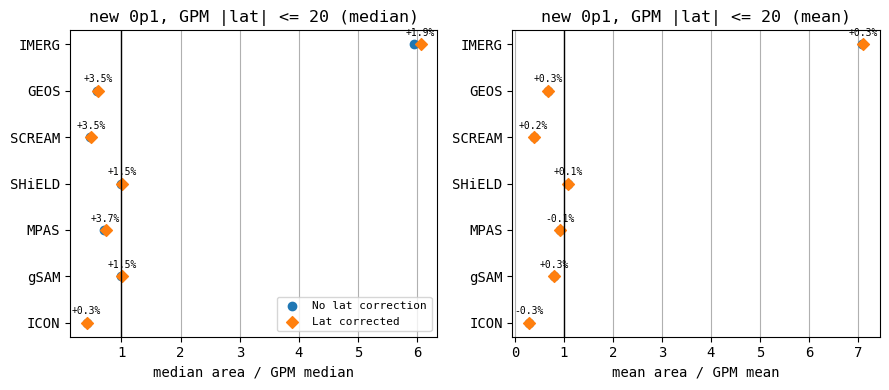

In [15]:
# The new GPM features run to |lat| ~ 60 while DYAMOND stops at 20, so the ratios above mix
# the correction with a domain mismatch. Repeat on a matched domain to separate the two.
gpm_new = new_features['GPM']
in_tropics = gpm_new['centroid_lat'].abs() <= 20
print(f'GPM features inside |lat| <= 20: {in_tropics.mean():.1%}')

matched = dict(areas['new 0p1'])
matched['GPM'] = {
    key: series.filter(in_tropics) for key, series in areas['new 0p1']['GPM'].items()
}

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, stat in zip(axes, ['median', 'mean']):
    _, d = plot_ratio_shift(matched, stat=stat, ax=ax, title=f'new 0p1, GPM |lat| <= 20 ({stat})')
    for source, (ru, rc, fl) in d.items():
        print(f'matched {stat:6s} {source:7s} {ru:6.3f} -> {rc:6.3f}' + ('  <-- FLIPS' if fl else ''))
axes[0].legend(fontsize=8, loc='lower right')
fig.tight_layout()

**Second question:** does the over/underestimate answer change between 0p1 and 0p05?

The new pipeline only has DYAMOND at 0p1 so far, so the model side comes from the archived
(no in-swath counting) CSVs, which exist at both resolutions for GEOS, SHiELD and ICON.
GPM is the current pipeline at both resolutions.

In [16]:
# Load the three models that exist at both resolutions, with and without an edge cut.
# The edge cut is not identical on the two sides (GPM has perimeter_px so it can use a
# fraction, the archived files can only drop features touching a swath edge), so the
# no-cut version is the cleaner resolution comparison and the cut version is the check.
#
# AREA_MIN is a physical floor in km2 rather than a pixel count, since 4 px means 116 km2
# at 0p05 but 465 km2 at 0p1. Watch the effective floor printed below: the archived files
# were written with a 4 px minimum, so at 0p1 they cannot go below 465 km2 whatever we ask.
MODELS = {'GEOS': 'GEOS-3km', 'SHiELD': 'SHiELD-3km', 'ICON': 'ICON-SAP-5km'}
RESOLUTIONS = ['0p1', '0p05']
AREA_MIN = 150
CUTS = {
    'no edge cut': dict(gpm=None, model=None),
    'edge cut': dict(gpm=0.5, model=0),
}

res_areas = {}
for label, cut in CUTS.items():
    for res in RESOLUTIONS:
        sources = {
            'GPM': load_gpm_feature_stats(
                1.0, res, maxpr_min=10, edge_frac_max=cut['gpm'], area_min=AREA_MIN
            )
        }
        for name, model in MODELS.items():
            sources[name] = load_archived_dyamond_feature_stats(
                model, res=res, maxpr_min=10, swath_edge_px_max=cut['model'], area_min=AREA_MIN
            )
        res_areas[(label, res)] = sources

for (label, res), sources in res_areas.items():
    print(f'\n{label}, {res}')
    for source, df in sources.items():
        print(f'  {source:7s} n={df.height:8d} floor={df["area_km2"].min():7.1f} '
              f'median={df["area_km2"].median():8.0f} mean={df["area_km2"].mean():9.0f} '
              f'median_px={df["size_px"].median():5.0f}')

# The largest floor anything actually has, i.e. the smallest size every source can resolve
EFFECTIVE_FLOOR = max(
    df['area_km2'].min() for sources in res_areas.values() for df in sources.values()
)
print(f'\nsmallest size common to every source and resolution: {EFFECTIVE_FLOOR:.0f} km2')


no edge cut, 0p1
  GPM     n=   26823 floor=  182.2 median=    1977 mean=     4898 median_px=   16
  GEOS    n=  185403 floor=  465.3 median=    1351 mean=     3467 median_px=   11
  SHiELD  n=  128825 floor=  465.3 median=    1853 mean=     4903 median_px=   15
  ICON    n=  405524 floor=  465.3 median=     742 mean=     1340 median_px=    6

no edge cut, 0p05
  GPM     n=   78549 floor=  150.0 median=     544 mean=     1773 median_px=   18
  GEOS    n=  394620 floor=  150.0 median=     522 mean=     1588 median_px=   17
  SHiELD  n=  293383 floor=  150.0 median=     629 mean=     2072 median_px=   21
  ICON    n=  733445 floor=  150.0 median=     402 mean=      706 median_px=   13

edge cut, 0p1
  GPM     n=   26136 floor=  182.2 median=    2084 mean=     5011 median_px=   17
  GEOS    n=  123653 floor=  465.3 median=    1096 mean=     1636 median_px=    9
  SHiELD  n=   77688 floor=  465.3 median=    1338 mean=     2093 median_px=   11
  ICON    n=  313252 floor=  465.3 median=    

median no edge cut  GEOS    0p1= 0.683 0p05= 0.960
median no edge cut  SHiELD  0p1= 0.937 0p05= 1.158  <-- SIGN FLIPS
median no edge cut  ICON    0p1= 0.375 0p05= 0.739
median edge cut     GEOS    0p1= 0.526 0p05= 0.803
median edge cut     SHiELD  0p1= 0.642 0p05= 0.932
median edge cut     ICON    0p1= 0.353 0p05= 0.722
mean   no edge cut  GEOS    0p1= 0.708 0p05= 0.896
mean   no edge cut  SHiELD  0p1= 1.001 0p05= 1.169
mean   no edge cut  ICON    0p1= 0.274 0p05= 0.398
mean   edge cut     GEOS    0p1= 0.327 0p05= 0.468
mean   edge cut     SHiELD  0p1= 0.418 0p05= 0.561
mean   edge cut     ICON    0p1= 0.208 0p05= 0.325


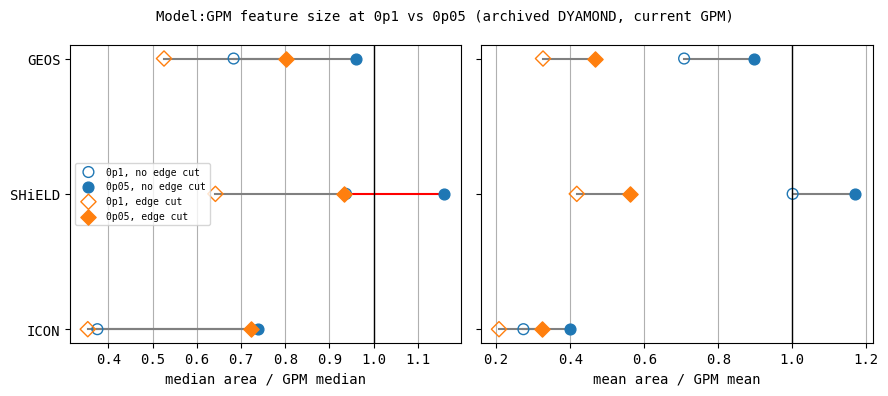

In [17]:
# Model:GPM size ratio at each resolution. A segment crossing 1 means the answer to
# "over or underestimated" depends on the resolution.
fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=True)

for ax, stat in zip(axes, ['median', 'mean']):
    names = list(MODELS)
    y = np.arange(len(names))[::-1]
    for label, marker, color in [('no edge cut', 'o', 'tab:blue'), ('edge cut', 'D', 'tab:orange')]:
        r = np.array([
            [getattr(res_areas[(label, res)][name]['area_km2'], stat)()
             / getattr(res_areas[(label, res)]['GPM']['area_km2'], stat)()
             for res in RESOLUTIONS]
            for name in names
        ])
        for yi, (r_coarse, r_fine) in zip(y, r):
            flips = (r_coarse - 1) * (r_fine - 1) < 0
            ax.plot([r_coarse, r_fine], [yi, yi], color='red' if flips else 'gray', lw=1.5, zorder=1)
            print(f'{stat:6s} {label:12s} {names[list(y).index(yi)]:7s} '
                  f'0p1={r_coarse:6.3f} 0p05={r_fine:6.3f}' + ('  <-- SIGN FLIPS' if flips else ''))
        ax.scatter(r[:, 0], y, marker=marker, facecolor='none', edgecolor=color, s=60, zorder=2,
                   label=f'0p1, {label}')
        ax.scatter(r[:, 1], y, marker=marker, color=color, s=60, zorder=2,
                   label=f'0p05, {label}')
    ax.axvline(1, color='black', lw=1)
    ax.set_yticks(y)
    ax.set_yticklabels(names)
    ax.set_xlabel(f'{stat} area / GPM {stat}')
    ax.grid(axis='x')
    ax.set_axisbelow(True)

axes[0].legend(fontsize=7, loc='best')
fig.suptitle('Model:GPM feature size at 0p1 vs 0p05 (archived DYAMOND, current GPM)', fontsize=10)
fig.tight_layout()

fraction of features <= 4 px (no edge cut)
  0p1   GPM=11.0%  GEOS=12.3%  SHiELD=7.4%  ICON=24.5%
  0p05  GPM=0.0%  GEOS=0.0%  SHiELD=0.0%  ICON=0.0%


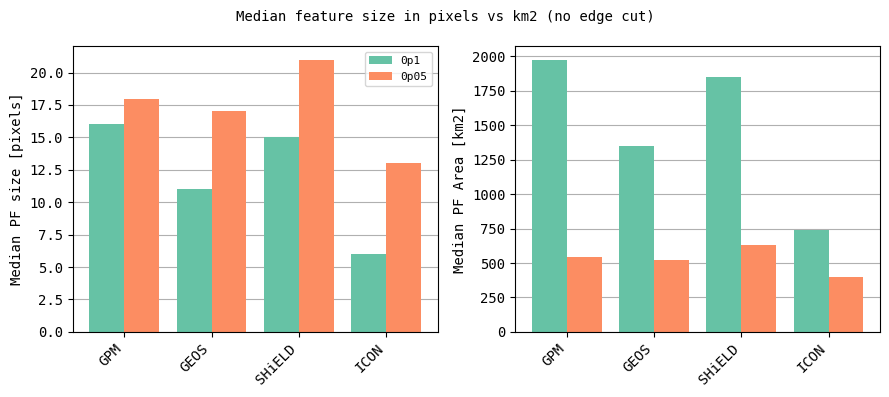

In [18]:
# Why resolution moves the ratio so much: in pixels the median feature is ~10-20 px at both
# resolutions, i.e. the median tracks the detection limit rather than a physical size, and
# each source resolves a different number of marginal small features.
fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=False)
label = 'no edge cut'
names = ['GPM'] + list(MODELS)
x = np.arange(len(names))
w = 0.4

for xi, (ax, quantity, ylabel) in enumerate(zip(
    axes, ['size_px', 'area_km2'], ['Median PF size [pixels]', 'Median PF Area [km2]']
)):
    for i, res in enumerate(RESOLUTIONS):
        vals = [res_areas[(label, res)][s][quantity].median() for s in names]
        ax.bar(x + (i - 0.5)*w, vals, w, label=res)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=45, ha='right')
    ax.set_ylabel(ylabel)
    ax.grid(axis='y')
    ax.set_axisbelow(True)

axes[0].legend(fontsize=8)
fig.suptitle(f'Median feature size in pixels vs km2 ({label})', fontsize=10)
fig.tight_layout()

print(f'fraction of features <= 4 px ({label})')
for res in RESOLUTIONS:
    fracs = {s: (res_areas[(label, res)][s]['size_px'] <= 4).mean() for s in names}
    print(f'  {res:5s} ' + '  '.join(f'{s}={f:.1%}' for s, f in fracs.items()))

smallest feature kept by each source
  0p1   GPM     min  2 px =   182.2 km2
  0p1   GEOS    min  4 px =   465.3 km2
  0p1   SHiELD  min  4 px =   465.3 km2
  0p1   ICON    min  4 px =   465.3 km2
  0p05  GPM     min  5 px =   150.0 km2
  0p05  GEOS    min  5 px =   150.0 km2
  0p05  SHiELD  min  5 px =   150.0 km2
  0p05  ICON    min  5 px =   150.0 km2


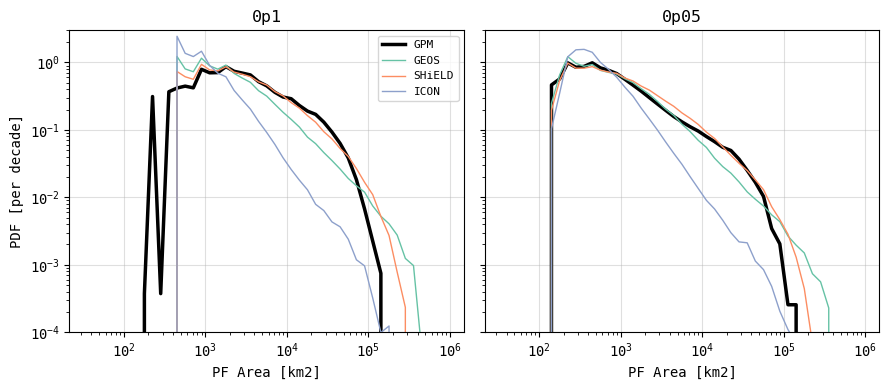

In [19]:
# The medians hide where in the distribution the models differ, so look at the full PDFs.
# Reuse the no-edge-cut load from above; PDFs are per decade of area so they integrate to 1.
CUT_LABEL = 'no edge cut'
BINS = np.logspace(1.5, 6, 46)
MID = array_midpoints(BINS)


def pdf_of(area, bins=BINS):
    counts = binned_statistic(area, None, 'count', bins=bins).statistic
    return counts / counts.sum() / np.diff(np.log10(bins))


pdfs = {}
fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=True)
for ax, res in zip(axes, RESOLUTIONS):
    for source, df in res_areas[(CUT_LABEL, res)].items():
        pdfs[(res, source)] = pdf_of(df['area_km2'])
        ax.plot(MID, pdfs[(res, source)], label=source,
                color='black' if source == 'GPM' else None,
                lw=2.5 if source == 'GPM' else 1)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylim(1e-4, 3)
    ax.set_xlabel('PF Area [km2]')
    ax.set_title(res)
    ax.grid(alpha=0.4)

axes[0].set_ylabel('PDF [per decade]')
axes[0].legend(fontsize=8)
fig.tight_layout()

# The distributions do not share a low-end support: the archived models impose a 4 px
# minimum, and GPM only does at 0p05, so at 0p1 GPM has 1-3 px features the models cannot.
print('smallest feature kept by each source')
for res in RESOLUTIONS:
    for source, df in res_areas[(CUT_LABEL, res)].items():
        print(f'  {res:5s} {source:7s} min {df["size_px"].min():2.0f} px = {df["area_km2"].min():7.1f} km2')

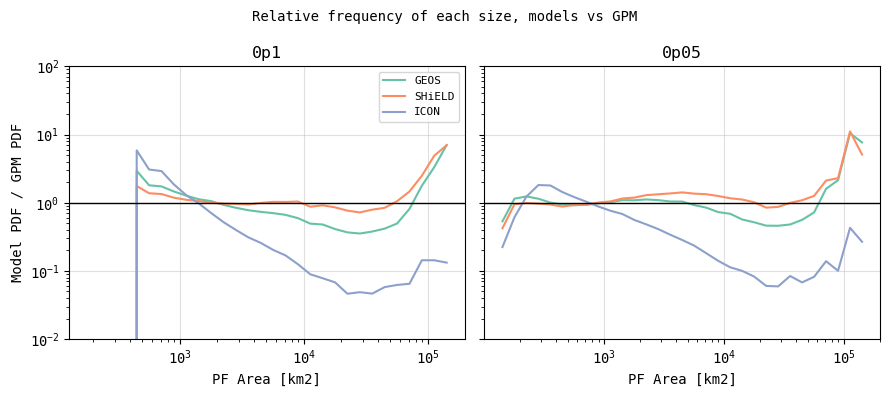

In [20]:
# Model PDF / GPM PDF: above 1 the model has relatively more features of that size.
# The crossover point is what a single median number collapses into one sign.
fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=True)

for ax, res in zip(axes, RESOLUTIONS):
    ref = pdfs[(res, 'GPM')]
    for source in MODELS:
        with np.errstate(divide='ignore', invalid='ignore'):
            ax.plot(MID, pdfs[(res, source)] / ref, label=source)
    ax.axhline(1, color='black', lw=1)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylim(1e-2, 1e2)
    ax.set_xlabel('PF Area [km2]')
    ax.set_title(res)
    ax.grid(alpha=0.4)

axes[0].set_ylabel('Model PDF / GPM PDF')
axes[0].legend(fontsize=8)
fig.suptitle('Relative frequency of each size, models vs GPM', fontsize=10)
fig.tight_layout()

--- 0p1, floor 150 km2, n(GPM)=26823
    GEOS      1.00   0.76   0.68   0.60   0.52   0.87
    SHiELD    1.23   0.99   0.94   0.95   0.89   1.17
    ICON      0.98   0.60   0.38   0.28   0.19   0.21
--- 0p05, floor 150 km2, n(GPM)=78549
    GEOS      1.13   0.94   0.96   0.99   0.84   0.72
    SHiELD    1.15   1.04   1.16   1.30   1.26   1.06
    ICON      1.26   0.99   0.74   0.56   0.37   0.20
--- 0p1, floor 465 km2, n(GPM)=24991
    GEOS      0.69   0.67   0.61   0.56   0.49   0.85
    SHiELD    0.85   0.87   0.84   0.88   0.84   1.15
    ICON      0.67   0.53   0.34   0.26   0.18   0.20
--- 0p05, floor 465 km2, n(GPM)=43398
    GEOS      1.01   1.03   1.03   0.93   0.75   0.88
    SHiELD    1.01   1.08   1.16   1.18   1.06   1.07
    ICON      0.93   0.86   0.71   0.52   0.33   0.25


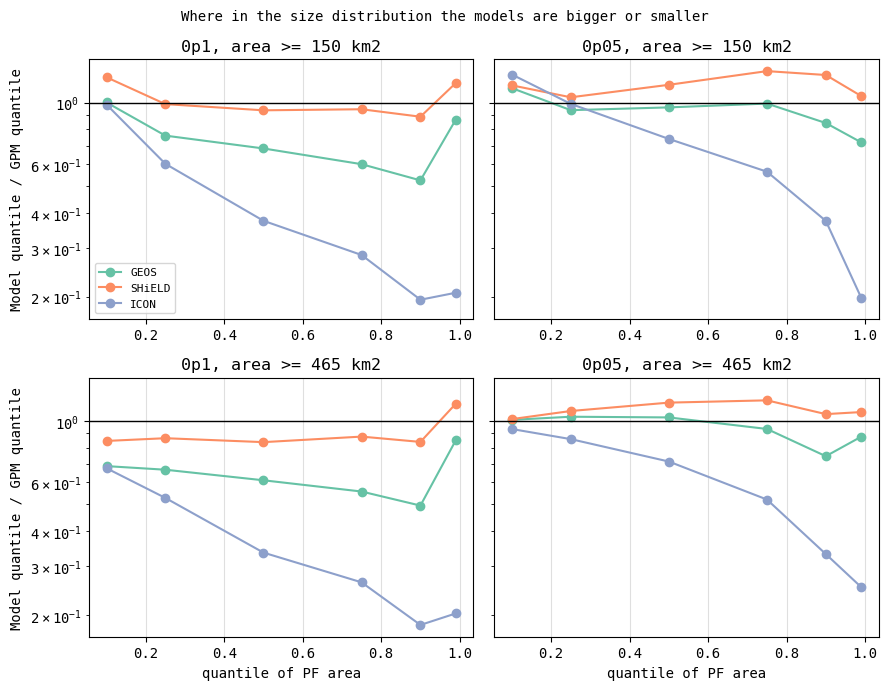

In [21]:
# Quantile by quantile. Top row uses AREA_MIN as requested at load time; bottom row tightens
# every source to EFFECTIVE_FLOOR, the smallest size all of them can actually resolve, which
# is the only floor that means the same thing at both resolutions.
QUANTILES = [0.1, 0.25, 0.5, 0.75, 0.9, 0.99]

fig, axes = plt.subplots(2, 2, figsize=(9, 7), sharey=True)
for row, floor in enumerate([AREA_MIN, EFFECTIVE_FLOOR]):
    for col, res in enumerate(RESOLUTIONS):
        ax = axes[row, col]
        sources = {
            s: df.filter(df['area_km2'] >= floor)
            for s, df in res_areas[(CUT_LABEL, res)].items()
        }
        gq = np.array([sources['GPM']['area_km2'].quantile(q) for q in QUANTILES])
        print(f'--- {res}, floor {floor:.0f} km2, n(GPM)={sources["GPM"].height}')
        for source in MODELS:
            mq = np.array([sources[source]['area_km2'].quantile(q) for q in QUANTILES])
            ax.plot(QUANTILES, mq / gq, marker='o', label=source)
            print(f'    {source:7s}' + ''.join(f'{v:7.2f}' for v in mq / gq))
        ax.axhline(1, color='black', lw=1)
        ax.set_yscale('log')
        ax.set_title(f'{res}, area >= {floor:.0f} km2')
        ax.grid(alpha=0.4)
        if row == 1:
            ax.set_xlabel('quantile of PF area')

axes[0, 0].set_ylabel('Model quantile / GPM quantile')
axes[1, 0].set_ylabel('Model quantile / GPM quantile')
axes[0, 0].legend(fontsize=8)
fig.suptitle('Where in the size distribution the models are bigger or smaller', fontsize=10)
fig.tight_layout()